In [72]:
import numpy as np
import pandas as pd

In [80]:
class MiniBatch_gradient_descent:
    def __init__(self,batch_size,learning_rate=0.01,epochs=100):
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.cost_ = []

    def fit(self,X_train,y_train):
        self.intercept_ = 0;
        self.coef_ = np.ones(X_train.shape[1])
        num_batches = X_train.shape[0] // self.batch_size

        for i in range(self.epochs):
            epoch_cost = 0

            indices = np.random.permutation(X_train.shape[0])
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            for j in range(num_batches):
                start = j * self.batch_size
                end = start + self.batch_size

                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                y_pred = np.dot(X_batch,self.coef_) + self.intercept_

                epoch_cost += np.mean((y_batch - y_pred)**2) 
                
                
                intercept_der = -2*np.mean(y_batch - y_pred)
                self.intercept_ -=  (self.lr * intercept_der)

                coef_der = (-2 * np.dot((y_batch - y_pred) , X_batch)) / self.batch_size
                self.coef_ -= self.lr * coef_der

            self.cost_.append(epoch_cost/num_batches)     

    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [81]:
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True)

In [82]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3)

In [94]:
from sklearn.metrics import r2_score

my_lr = MiniBatch_gradient_descent(batch_size = 32,learning_rate = 0.06,epochs=800)
my_lr.fit(X_train,y_train)
pred = my_lr.predict(X_test)
print("My model R2:", r2_score(y_test, pred))

My model R2: 0.39395884194786657


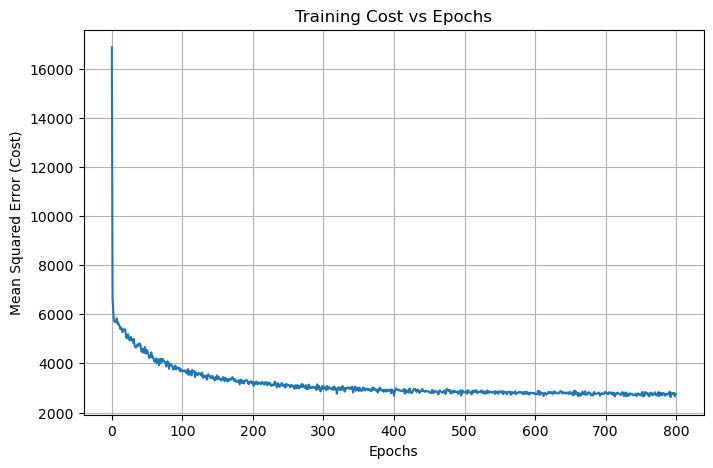

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(my_lr.cost_)

plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (Cost)")
plt.title("Training Cost vs Epochs")

plt.grid(True)

plt.show()

In [96]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Sklearn R2:", r2_score(y_test, lr_pred))

Sklearn R2: 0.39512674159821737
